## 1. Importing the libraries :- 

In [29]:
# For data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For model training 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# For evaluation
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## 2. Loading the datasets :-

In [30]:
power_demand = pd.read_csv("PGCB_date_power_demand.csv") 
weather = pd.read_csv("weather_data.csv", header=3) # Taking 3rd row as column names
economy = pd.read_csv("economic_full_1.csv")

## 3. Helper functions :-

In [31]:
# Using IQR method for outlier handling
def clip_iqr(s):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return s.clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# For mean absolute percentage error
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


## 4. Power Demand data preprocessing :-

In [32]:
# converting to datetime format
power_demand['datetime'] = pd.to_datetime(power_demand['datetime'])
power_demand = power_demand.sort_values('datetime').set_index('datetime')

# dropping 'remarks' column as it is non-numeric
power_demand = power_demand.drop(columns=['remarks'], errors='ignore')

# converting every column to numeric form
for col in power_demand.columns:
    power_demand[col] = pd.to_numeric(power_demand[col], errors='coerce')

# fixing full and half hour
hourly = power_demand[power_demand.index.minute == 0].copy()
half = power_demand[power_demand.index.minute == 30].copy()

# removing duplicate timestamps by taking mean of them
hourly = hourly.groupby(level=0).mean()
half = half.groupby(level=0).mean()

# shifting half hour to previous full hour(e.g - 2:30 to 2:00)
half.index = half.index - pd.Timedelta(minutes=30)

# combining both full and half hour after fixing
combined = hourly.copy()

# case-1 : when full and half hour both exists(e.g - both 2:00 and 2:30 available in the data)
common_idx = hourly.index.intersection(half.index)
# taking weighted average(50% full and 50% half)
combined.loc[common_idx] = (
    0.5 * hourly.loc[common_idx] +
    0.5 * half.loc[common_idx]
)
# Case-2: only half hour exists - take half(e.g - only 2:30 available)
combined = combined.combine_first(half)

# sorting newly combined data
combined = combined.sort_index()

# we want hourly data, if both half and full hour doesn't exist in the data :-
#  create missing hours and fill with prev values
full_index = pd.date_range(
    start=combined.index.min(),
    end=combined.index.max(),
    freq='h'
)
# re-indexing new data
combined = combined.reindex(full_index)

# dropping 3 columns as there are too many NaN....these can create wrong predictions
combined = combined.drop(columns=['wind', 'india_adani', 'nepal'])
combined['solar'] = combined['solar'].fillna(0)

# scaling all columns using IQR method
for col in combined.columns:
        combined[col] = clip_iqr(combined[col])

combined = combined.ffill()

# storing all processed new data in a new variable
power_demand_final  = combined.copy()

#power_demand_final.info()
power_demand_final.describe()
#power_demand_final.head(25)

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura
count,89101.000000,89101.000000,89101.0,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.00000
mean,8673.555929,8752.461983,0.0,5108.384887,1647.959919,870.806533,95.673631,7.580076,659.401309,93.02677
std,2485.838478,2614.378803,0.0,908.078894,1177.694980,983.009916,60.446010,12.518458,234.712702,44.19929
min,1158.000000,1037.500000,0.0,2328.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,6744.000000,6742.000000,0.0,4408.000000,695.000000,159.000000,40.000000,0.000000,464.000000,69.00000
50%,8347.100000,8357.000000,0.0,5015.000000,1473.000000,400.000000,78.000000,0.000000,701.000000,96.00000
75%,10500.000000,10571.000000,0.0,5807.000000,2401.000000,1214.000000,149.000000,12.600000,910.000000,125.00000
max,16142.000000,16337.500000,0.0,7903.687500,4983.500000,2860.000000,315.000000,31.500000,1576.000000,210.00000


## 5. Weather data preprocessing :-

In [33]:
# renaming 'time' column to 'datetime' and changing to datetime format
weather = weather.rename(columns={'time': 'datetime'})
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather = weather.drop_duplicates(subset='datetime')
weather = weather.sort_values('datetime').set_index('datetime')

# converting every column to numeric form
for col in weather.columns:
    if col != 'datetime':
        weather[col] = pd.to_numeric(weather[col], errors='coerce')

# these columns contain too many similar values ...so dropping them is efficient
weather = weather.drop(columns = ['cloud_cover (%)',
                        'sunshine_duration (s)',
                        'precipitation (mm)',
                        ])

#weather.info()
weather.describe()
#weather.head(50)

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°)
count,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000
mean,25.457445,76.806233,28.804437,20.633153,26.769709,195.691260
std,5.033014,16.454697,6.905288,5.231144,4.908599,94.451905
min,8.400000,15.000000,6.600000,2.500000,11.700000,1.000000
25%,22.600000,67.000000,24.200000,15.800000,23.800000,136.000000
50%,26.500000,81.000000,30.800000,22.800000,27.600000,180.000000
75%,28.800000,90.000000,33.700000,25.200000,29.900000,286.000000
max,40.800000,100.000000,45.600000,28.600000,44.500000,360.000000


## 6. Economic data preprocessing :-

In [34]:
# storing years(e.g - 2016,2017...)
years = [c for c in economy.columns if c.isdigit()]

# selected features based on their relation with demand
features = [
    'GDP (current US$)',
    'GDP per capita (current US$)',
    'GDP growth (annual %)',
    'Industry (including construction), value added (current US$)',
    'Industry (including construction), value added (annual % growth)',
    'Final consumption expenditure (current US$)',
    'Population, total',
    'Urban population (% of total population)',
    'Urban population growth (annual %)',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
]

economy= economy[economy['Indicator Name'].isin(features)]
economy = economy[['Indicator Name'] + years]

# converting to long format
economy = economy.melt(
    id_vars='Indicator Name',
    var_name='year',
    value_name='value'
)

# converting year indices to int
economy['year'] = economy['year'].astype(int)
economy['value'] = pd.to_numeric(economy['value'], errors='coerce')

# changing columns into rows and vice-versa
economy = economy.pivot(
    index='year',
    columns='Indicator Name',
    values='value'
)

# filling missing values(if any)
economy = economy.ffill().bfill()

#economy.info()
economy.describe()
#economy.head(60)

Indicator Name,Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Final consumption expenditure (current US$),GDP (current US$),GDP growth (annual %),GDP per capita (current US$),"Industry (including construction), value added (annual % growth)","Industry (including construction), value added (current US$)","Population, total",Urban population (% of total population),Urban population growth (annual %)
count,66.000000,6.600000e+01,6.600000e+01,66.000000,66.000000,66.000000,6.600000e+01,6.600000e+01,66.000000,66.000000
mean,35.375823,7.251099e+10,9.397765e+10,4.426236,624.410945,7.034081,2.754632e+10,1.152906e+08,19.453887,4.775488
std,38.740446,9.776583e+10,1.321171e+11,3.593744,756.412805,12.901943,4.491706e+10,3.841659e+07,8.918192,2.625649
min,3.339300,3.950699e+09,4.274894e+09,-13.973729,82.481277,-46.684849,2.981232e+08,5.182866e+07,5.112178,1.718184
25%,5.608125,1.258262e+10,1.270479e+10,3.557021,159.989790,3.904117,1.730089e+09,8.035830e+07,10.814179,2.820159
50%,16.343000,2.819995e+10,3.243770e+10,5.099283,280.680153,7.032868,7.246497e+09,1.170423e+08,20.825589,3.657796
75%,54.179875,7.974271e+10,9.976550e+10,6.363549,662.674118,9.580335,2.510603e+10,1.505239e+08,27.201359,6.437973
max,124.190700,3.440660e+11,4.601320e+11,10.952789,2716.485928,69.689988,1.560770e+11,1.735624e+08,32.678320,11.986859


## 7. Merging weather and economy with power demand dataset :-

In [35]:
# merging weather with power demand data according to timestamps
final_data = power_demand_final.join(weather, how='left')

# changing index to column for merging yearly economy data
final_data.index.name = 'datetime'
final_data = final_data.reset_index()
final_data['year'] = final_data['datetime'].dt.year

# merging economy data according to year
final_data = final_data.merge(economy.reset_index(), on='year', how='left')
final_data = final_data.set_index('datetime').sort_index()

# keeping data till 2024
final_data = final_data[final_data.index.year <= 2024]
final_data = final_data.ffill() # handles missing values

# removing special character as lightGBM can't handle those
final_data.columns = (
    final_data.columns
    .str.replace('[^A-Za-z0-9_]', '_', regex=True)
    .str.lower()
)
#final_data.info()
final_data.describe()
#final_data.head(50)

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,...,carbon_dioxide__co2__emissions__total__excluding_lulucf__mt_co2e_,final_consumption_expenditure__current_us__,gdp__current_us__,gdp_growth__annual___,gdp_per_capita__current_us__,industry__including_construction___value_added__annual___growth_,industry__including_construction___value_added__current_us__,population__total,urban_population____of_total_population_,urban_population_growth__annual___
count,85080.000000,85080.000000,85080.0,85080.000000,85080.000000,85080.000000,85080.000000,85080.000000,85080.000000,85080.000000,...,85080.000000,8.508000e+04,8.508000e+04,85080.000000,85080.000000,85080.000000,8.508000e+04,8.508000e+04,85080.000000,85080.000000
mean,8538.063162,8618.674655,0.0,5103.867153,1676.199086,783.194011,97.739359,7.238145,649.119717,95.222405,...,108.781389,2.681179e+11,3.613817e+11,6.285232,2165.074547,8.615738,1.187000e+11,1.661188e+08,31.042923,2.069097
std,2420.229052,2558.692997,0.0,912.848759,1182.214553,915.690284,60.563350,12.259221,234.532420,43.902064,...,11.420610,6.050445e+10,7.964673e+10,1.366513,430.662093,2.766688,3.127733e+10,4.317871e+06,0.932531,0.374502
min,1158.000000,1037.500000,0.0,2328.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,85.445200,1.519050e+11,1.951470e+11,3.448018,1224.386477,3.506181,5.236056e+10,1.593832e+08,29.539510,1.718184
25%,6669.000000,6667.000000,0.0,4400.000000,721.000000,156.000000,44.000000,0.000000,462.000000,72.000000,...,101.041500,2.142320e+11,2.937320e+11,5.775112,1811.082217,8.272165,9.178637e+10,1.621861e+08,30.201580,1.841763
50%,8216.450000,8223.000000,0.0,5004.000000,1509.500000,364.000000,80.000000,0.000000,668.000000,98.000000,...,109.322200,2.727150e+11,3.739790e+11,6.938679,2248.850788,9.855663,1.230820e+11,1.662980e+08,31.116893,1.894721
75%,10291.000000,10352.000000,0.0,5809.000000,2431.000000,929.000000,150.000000,10.000000,907.000000,126.000000,...,118.989100,3.247390e+11,4.374150e+11,7.113478,2551.017738,10.287115,1.513210e+11,1.693849e+08,31.673735,2.068846
max,16142.000000,16337.500000,0.0,7903.687500,4983.500000,2860.000000,315.000000,31.500000,1576.000000,210.000000,...,124.190700,3.440660e+11,4.601320e+11,7.881915,2716.485928,11.633323,1.560770e+11,1.735624e+08,32.678320,2.820159


## 8. Feature engineering using lag and rolling :-

In [36]:
# timewise breakdown of power demand(e.g - more demand on summer)
final_data['hour'] = final_data.index.hour
final_data['day'] = final_data.index.dayofweek
final_data['month'] = final_data.index.month
final_data['quarter'] = final_data.index.quarter
final_data['is_weekend'] = final_data['day'].isin([5,6]).astype(int)

# lag features:- model get to know about previous patterns too
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
        final_data[f'lag_{lag}h'] = final_data['demand_mw'].shift(lag)

# cyclical encoding:- prevents artificial discontinuity at period wraparound(e.g- 23:00->00:00)
final_data['hour_sin'] = np.sin(2 * np.pi * final_data['hour'] / 24)
final_data['hour_cos'] = np.cos(2 * np.pi * final_data['hour'] / 24)
final_data['day_sin'] = np.sin(2 * np.pi * final_data['day'] / 7)
final_data['day_cos'] = np.cos(2 * np.pi * final_data['day'] / 7)
final_data['month_sin'] = np.sin(2 * np.pi * final_data['month'] / 12)
final_data['month_cos'] = np.cos(2 * np.pi * final_data['month'] / 12)

# rolling:- taking average demand of past hours
for w in [3, 6, 12, 24, 168]:
        final_data[f'roll_mean_{w}h'] = final_data['demand_mw'].shift(1).rolling(w).mean()
        final_data[f'roll_std_{w}h'] = final_data['demand_mw'].shift(1).rolling(w).std()

# target:- we want next hour demand so shifting next hour demand to current hour to learn pattern
final_data['target'] = final_data['demand_mw'].shift(-1)

#dropping some first and last rows as shifting causes NaN values
final_data = final_data.dropna()

# as any type of power generation data comes under data leakage so those should be removed
final_data = final_data.drop(columns = [
                    'generation_mw','demand_mw','load_shedding',
                    'gas','liquid_fuel','coal','hydro',
                    'solar','india_bheramara_hvdc','india_tripura','year'
                                ])
#final_data.info()
final_data.describe()
#final_data.head(50)

,temperature_2m___c_,relative_humidity_2m____,apparent_temperature___c_,dew_point_2m___c_,soil_temperature_0_to_7cm___c_,wind_direction_10m____,carbon_dioxide__co2__emissions__total__excluding_lulucf__mt_co2e_,final_consumption_expenditure__current_us__,gdp__current_us__,gdp_growth__annual___,...,roll_std_3h,roll_mean_6h,roll_std_6h,roll_mean_12h,roll_std_12h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h,target
count,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,8.491100e+04,8.491100e+04,84911.000000,...,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000,84911.000000
mean,25.491072,77.867355,28.952182,20.949108,26.652175,191.778074,108.827379,2.683470e+11,3.617096e+11,6.284727,...,322.668155,8625.320920,534.189947,8625.162148,787.900428,8624.838216,968.151278,8621.677362,1107.984566,8625.495745
std,5.018215,15.599926,6.914418,5.135529,4.805158,93.947279,11.384531,6.034266e+10,7.938106e+10,1.367802,...,342.467707,2488.693940,351.011851,2421.035057,336.782746,2358.030425,283.535201,2286.918143,311.697599,2556.130797
min,8.400000,15.000000,6.600000,2.500000,11.700000,1.000000,85.445200,1.519050e+11,1.951470e+11,3.448018,...,0.000000,1920.166667,0.000000,2464.500000,0.000000,3653.687500,0.000000,4497.413690,0.000000,1037.500000
25%,22.700000,69.000000,24.500000,16.400000,23.800000,135.000000,101.041500,2.142320e+11,2.937320e+11,5.775112,...,139.031771,6721.208333,303.771241,6768.187500,579.934292,6785.833333,833.510900,6799.967262,947.713578,6674.000000
50%,26.500000,82.000000,31.000000,23.200000,27.600000,177.000000,109.322200,2.727150e+11,3.739790e+11,6.938679,...,245.880052,8207.166667,492.841827,8175.083333,764.335520,8146.062500,960.651330,8110.654762,1056.190372,8229.000000
75%,28.800000,90.000000,33.800000,25.300000,29.800000,276.000000,118.989100,3.247390e+11,4.374150e+11,7.113478,...,406.034892,10315.666667,705.946283,10289.770833,955.134244,10266.416667,1067.500772,10283.422619,1209.752826,10357.000000
max,40.800000,100.000000,45.600000,28.600000,43.500000,360.000000,124.190700,3.440660e+11,4.601320e+11,7.881915,...,7988.618988,16337.500000,5797.729441,16265.625000,4227.001252,15924.479167,3625.416246,15306.309524,3799.334776,16337.500000


## 9. Splitting train and test data :-

In [37]:
# training upto 2023 , testing on 2024
train = final_data[final_data.index.year < 2024]
test = final_data[final_data.index.year == 2024]

# dropping target column from training data 
y_train = train['target']
X_train = train.drop(columns=['target'])

# dropping target column from test data
y_test = test['target']
X_test = test.drop(columns=['target'])

X_train.describe()
#y_train.describe()

,temperature_2m___c_,relative_humidity_2m____,apparent_temperature___c_,dew_point_2m___c_,soil_temperature_0_to_7cm___c_,wind_direction_10m____,carbon_dioxide__co2__emissions__total__excluding_lulucf__mt_co2e_,final_consumption_expenditure__current_us__,gdp__current_us__,gdp_growth__annual___,...,roll_mean_3h,roll_std_3h,roll_mean_6h,roll_std_6h,roll_mean_12h,roll_std_12h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h
count,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,7.612800e+04,7.612800e+04,76128.000000,...,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000,76128.000000
mean,25.457142,78.108042,28.931071,20.981229,26.615775,191.320946,107.054890,2.598167e+11,3.515097e+11,6.522561,...,8306.636658,316.938739,8306.568583,526.346268,8306.404975,778.438992,8306.067680,956.193636,8302.913246,1078.579224
std,4.961297,15.407105,6.862775,5.105306,4.741009,93.476711,10.685847,5.794707e+10,7.760501e+10,1.240916,...,2337.590420,327.230338,2296.923575,339.443890,2224.884059,326.110133,2158.058691,271.712051,2092.737653,281.433690
min,8.400000,16.000000,6.600000,2.500000,11.900000,1.000000,85.445200,1.519050e+11,1.951470e+11,3.448018,...,1799.000000,0.000000,1920.166667,0.000000,2464.500000,0.000000,3653.687500,0.000000,4497.413690,0.000000
25%,22.700000,69.000000,24.500000,16.500000,23.800000,135.000000,101.041500,2.142320e+11,2.937320e+11,6.552640,...,6539.000000,135.433871,6571.166667,294.486318,6622.833333,572.137941,6639.536458,825.979989,6663.206845,925.605764
50%,26.500000,82.000000,31.000000,23.300000,27.600000,176.000000,105.182300,2.568050e+11,3.512320e+11,6.938679,...,7946.500000,239.758559,7928.083333,484.081415,7876.895833,759.103043,7856.270833,955.518358,7801.001488,1040.522870
75%,28.800000,91.000000,33.800000,25.300000,29.700000,274.000000,117.768300,3.107810e+11,4.162720e+11,7.113478,...,9853.333333,400.430185,9846.354167,703.105334,9865.250000,950.573789,9840.791667,1058.845638,9855.420387,1181.227512
max,40.000000,100.000000,45.600000,28.200000,43.500000,360.000000,120.865700,3.440660e+11,4.601320e+11,7.881915,...,16056.166667,7434.898004,15911.416667,5583.796689,15237.166667,4144.886792,14816.875000,3616.219036,14336.101190,2778.023125


## 10. Model selection :-

In [ ]:
# using multiple models for filtering the best
models = {
    "LinearRegression": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=-1,
        random_state=42
    ),
}

## 11. Training and testing :-

Mean Absolute Percentage Error(MAPE) Scores:
LinearRegression : 5.882426541561463
DecisionTree : 5.175359395964339
RandomForest : 4.1808677412556206
XGBoost : 4.048835738575773
LightGBM : 3.9622812992271834


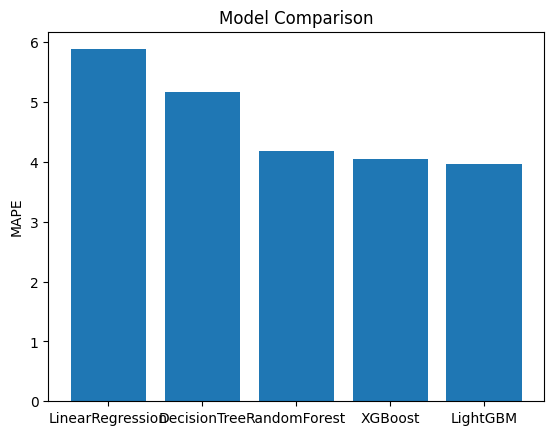

In [39]:
# storing outputs from various modes 
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)         # training
    pred = model.predict(X_test)        # testing
    results[name] = mape(y_test, pred)  # evaluation

print("Mean Absolute Percentage Error(MAPE) Scores:")
for k,v in results.items():
    print(k, ":", v)

# plotting and comparing results of different models
plt.bar(results.keys(), results.values())
plt.ylabel("MAPE")
plt.title("Model Comparison")
plt.show()

## 12. Feature importances :-

               feature  importance
0                 hour         850
1             hour_sin         753
2               lag_1h         751
3             hour_cos         537
4          roll_std_3h         383
5              lag_24h         352
6          roll_std_6h         317
7  temperature_2m___c_         262
8         roll_std_12h         261
9                month         257


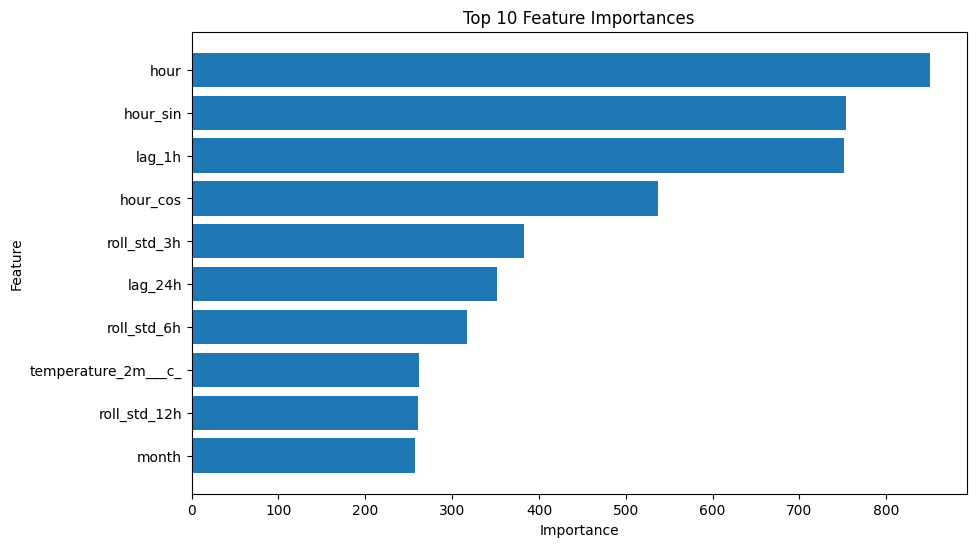

In [40]:
# taking the best model for important features extraction
best_model = models[min(results, key=results.get)]

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_ # for tree based models
else:
    importance = np.abs(best_model.coef_)   # for linear models

feature_names = X_train.columns

# creating dataframe by sorting importances
imp_features = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

imp_features = imp_features.reset_index(drop=True)
print(imp_features.head(10))
top_features = imp_features.head(10)

# visualization of feature importances
plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()  # highest on top
plt.show()

## 13. Plotting predicted vs actual data :-

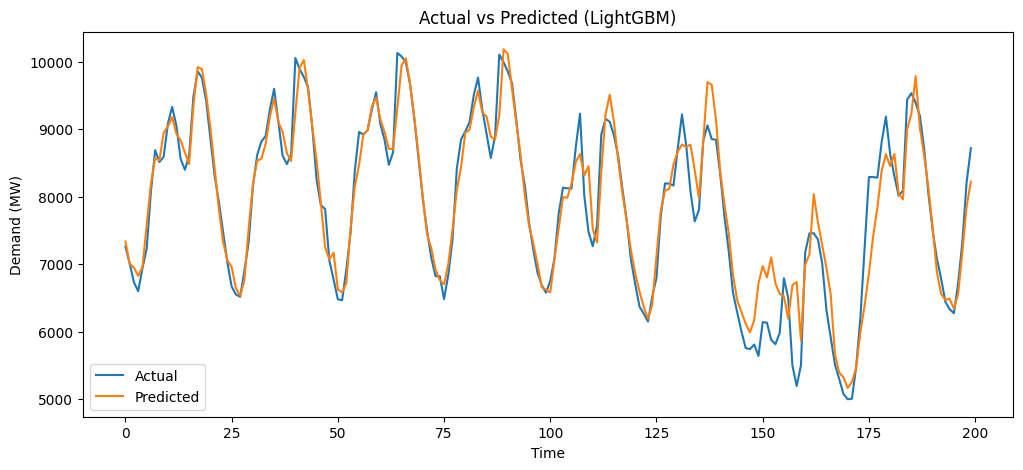

In [41]:
best_name = min(results, key=results.get)
best_model = models[best_name]

# retrain best model to get predicted data
best_model.fit(X_train, y_train)

# get predictions
best_pred = best_model.predict(X_test)

# plot predicted vs actual demand
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(best_pred[:200], label='Predicted')
plt.legend()
plt.title(f"Actual vs Predicted ({best_name})")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.show()